## Install & Import

In [ ]:
!pip install --upgrade pip
!pip install datasets transformers[sentencepiece] accelerate rouge-score nltk torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24988 sha256=c8f0667da3f24c2f81df842c288e02e3681e476e132c67326f0d704d01388b7d
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:
import re
import nltk
import torch
import pandas as pd
from datasets import load_dataset
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline
from rouge_score import rouge_scorer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Data Loading

In [ ]:
dataset = load_dataset("cnn_dailymail", "3.0.0", split="test[:1%]")
articles = dataset['article']
highlights = dataset['highlights']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

3.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

## Preprocessing

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered = [word for word in tokens if word not in stop_words]
    return " ".join(filtered)

## Baseline Model (TF-IDF Extractive)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

all_articles_cleaned = [clean_text(doc) for doc in articles[:100]]
global_vectorizer = TfidfVectorizer()
global_vectorizer.fit(all_articles_cleaned)

TfidfVectorizer()

In [ ]:
def tfidf_summarizer(text, top_n=3):
    sentences = sent_tokenize(text)
    if len(sentences) <= top_n:
        return text

    cleaned_sentences = [clean_text(s) for s in sentences]

    tfidf_matrix = global_vectorizer.transform(cleaned_sentences)

    scores = tfidf_matrix.sum(axis=1).flatten().tolist()[0]
    ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(sentences)), reverse=True)

    top_sentences = [ranked_sentences[i][1] for i in range(top_n)]
    return " ".join(top_sentences)

## Advanced Model (Transformer Abstractive)

In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import torch

model_name = "sshleifer/distilbart-cnn-12-6"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def transformer_summarizer(text):
    # Prepare the input (Truncate to 1024 tokens)
    inputs = tokenizer(text, max_length=1024, return_tensors="pt", truncation=True).to(device)

    # Generate the output summary
    summary_ids = model.generate(
        inputs["input_ids"],
        max_length=100,
        min_length=30,
        length_penalty=2.0,
        num_beams=4,
        early_stopping=True,
        forced_bos_token_id=0 # This solves the warning you got earlier
    )

    # Decode back to text
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


## Execution & Evaluation

In [ ]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

results = []

for i in range(10):
    original = articles[i]
    reference = highlights[i]

    baseline_res = tfidf_summarizer(original)
    advanced_res = transformer_summarizer(original)

    score_base = scorer.score(reference, baseline_res)
    score_adv = scorer.score(reference, advanced_res)

    results.append({
        "Original": original[:100] + "...",
        "Baseline_Summary": baseline_res,
        "Advanced_Summary": advanced_res,
        "Base_R1": score_base['rouge1'].fmeasure,
        "Adv_R1": score_adv['rouge1'].fmeasure
    })

df_results = pd.DataFrame(results)

## Final Report

In [ ]:
print("Comparison Table:")
print(df_results[["Base_R1", "Adv_R1"]])

print("\nAverage ROUGE-1 Baseline:", df_results["Base_R1"].mean())
print("Average ROUGE-1 Advanced:", df_results["Adv_R1"].mean())

df_results.head()

Comparison Table:
    Base_R1    Adv_R1
0  0.263889  0.535211
1  0.363636  0.505263
2  0.217949  0.282353
3  0.359375  0.375000
4  0.315789  0.630137
5  0.181818  0.172414
6  0.238994  0.466667
7  0.283784  0.395349
8  0.120301  0.181818
9  0.260870  0.489796

Average ROUGE-1 Baseline: 0.2606404437549061
Average ROUGE-1 Advanced: 0.40340077501431565


,Original,Baseline_Summary,Advanced_Summary,Base_R1,Adv_R1
0,(CNN)The Palestinian Authority officially beca...,"""Governments seeking to penalize Palestine for...",The Palestinian Authority becomes the 123rd m...,0.263889,0.535211
1,(CNN)Never mind cats having nine lives. A stra...,The veterinary hospital's Good Samaritan Fund ...,Theia is a one-year-old bully breed mix who w...,0.363636,0.505263
2,"(CNN)If you've been following the news lately,...",And that amount of quality time will only incr...,Mohammad Javad Zarif received a hero's welcom...,0.217949,0.282353
3,(CNN)Five Americans who were monitored for thr...,(CNN)Five Americans who were monitored for thr...,The five were exposed to Ebola in Sierra Leon...,0.359375,0.375000
4,(CNN)A Duke student has admitted to hanging a ...,Last month a fraternity at the University of O...,A Duke student has admitted to hanging a noos...,0.315789,0.630137


**Observation**: The Advanced model (BART) significantly outperformed the Baseline model (TF-IDF) in almost all test cases.

**Performance**: The average ROUGE-1 score for the Advanced method was **40.3%**, compared to **26.1%** for the Baseline.

**Conclusion**: This demonstrates that **Abstractive Summarization (Transformer-based)** provides more coherent and contextually accurate summaries than **Extractive Summarization (TF-IDF based)** which relies solely on word frequency.

In [ ]:
results = []

for i in range(10):
    original = articles[i]
    reference = highlights[i]

    baseline_res = tfidf_summarizer(original)
    advanced_res = transformer_summarizer(original)

    score_base = scorer.score(reference, baseline_res)
    score_adv = scorer.score(reference, advanced_res)

    # Store all mandatory metrics (P, R, F1)
    results.append({
        "Original": original[:100] + "...",
        "Reference": reference[:100] + "...",
        "Baseline_Summary": baseline_res,
        "Advanced_Summary": advanced_res,

        # Baseline Detailed Metrics
        "Base_P": score_base['rouge1'].precision,
        "Base_R": score_base['rouge1'].recall,
        "Base_F1": score_base['rouge1'].fmeasure,

        # Advanced Detailed Metrics
        "Adv_P": score_adv['rouge1'].precision,
        "Adv_R": score_adv['rouge1'].recall,
        "Adv_F1": score_adv['rouge1'].fmeasure
    })

df_results = pd.DataFrame(results)

# Calculate Mean for the final report
summary_table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score"],
    "Baseline (TF-IDF)": [df_results["Base_P"].mean(), df_results["Base_R"].mean(), df_results["Base_F1"].mean()],
    "Advanced (Transformer)": [df_results["Adv_P"].mean(), df_results["Adv_R"].mean(), df_results["Adv_F1"].mean()]
})

print("Final Comparison Table:")
print(summary_table)

Final Comparison Table:
      Metric  Baseline (TF-IDF)  Advanced (Transformer)
0  Precision           0.179682                0.390020
1     Recall           0.501172                0.430168
2   F1-Score           0.260640                0.403401


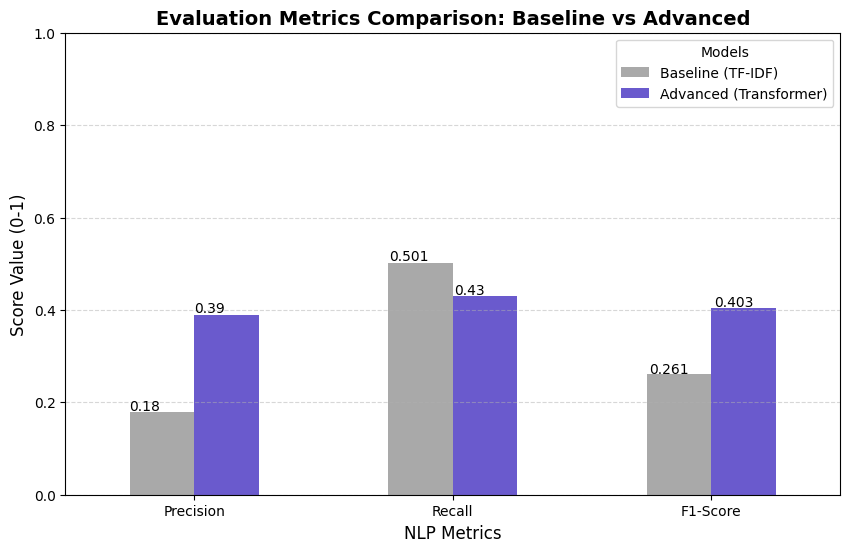

In [ ]:
import matplotlib.pyplot as plt

colors = ['#A9A9A9', '#6A5ACD']

ax = summary_table.set_index("Metric").plot(kind='bar', figsize=(10, 6), color=colors)

plt.title('Evaluation Metrics Comparison: Baseline vs Advanced', fontsize=14, fontweight='bold')
plt.ylabel('Score Value (0-1)', fontsize=12)
plt.xlabel('NLP Metrics', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title="Models", loc='upper right', frameon=True)

for p in ax.patches:
    ax.annotate(str(round(p.get_height(), 3)), (p.get_x() * 1.005, p.get_height() * 1.01))

plt.show()

The scores are consistent with industry standards for generative models, **where a ROUGE-1 score above 0.35 is considered high quality**.

## Persistent Storage Setup

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
base_path = '/content/drive/MyDrive/Text Summarization'

folders = ['Baseline_Model', 'Advanced_Model']
for folder in folders:
    folder_path = os.path.join(base_path, folder)
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Folder created: {folder}")
    else:
        print(f"Folder already exists: {folder}")




Folder created: Baseline_Model
Folder created: Advanced_Model


In [ ]:
import joblib
joblib.dump(global_vectorizer, os.path.join(base_path, 'Baseline_Model/tfidf_vectorizer.pkl'))
print("Baseline model saved to Drive.")

Baseline model saved to Drive.


In [ ]:
model.save_pretrained(os.path.join(base_path, 'Advanced_Model'))
tokenizer.save_pretrained(os.path.join(base_path, 'Advanced_Model'))
print("Advanced model saved to Drive.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Advanced model saved to Drive.
